# Career Market Intelligence

**Objective:** Predict the salary band (`low` / `medium` / `high`) of Indian job postings from role, seniority, location and required skills, and identify the factors that drive pay.

**Pipeline**
1. Data Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering
4. Predictive Modelling
5. Evaluation & Business Interpretation

**Data:** real job postings collected from the Adzuna API, with skill-interest trends from Google Trends.

# 1. Data Preprocessing

Transform the collected job-postings dataset into a clean, standardized, analysis-ready table: build the `salary_band` target, derive features, handle missing values and normalize the job-description text.

In [218]:
import re
import warnings
import pandas as pd
import numpy as np
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 100)

print("Environment setup completed.")

Environment setup completed.


## Step 1: Load Raw Dataset
We load `data/final/career_market_core_analysis.csv`, which contains 7,184 rows across 49 columns.

In [219]:
INPUT_PATH = "../data/final/career_market_core_analysis.csv"
OUTPUT_PATH = "../data/processed/career_market_preprocessed.csv"

df_raw = pd.read_csv(INPUT_PATH, low_memory=False)
print(f"Dataset Loaded Successfully: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Dataset Loaded Successfully: 7,240 rows x 49 columns


,job_id,title,role,role_scope,role_status,domain,role_group,mapping_tier,employer,employer_normalized,employer_missing,description_raw,location_display,location_area,location_country,...,source_query_role,collection_timestamp,collection_date,collection_method,query_roles_seen,also_seen_in,id_dup_count,near_dup_group_size,near_dup_key,employer_cap_status,in_core_analysis_dataset,description_length,description_is_truncated,description_short_flag,language_flag
0,5782883230,Technical Systems Analyst,Business Analyst,core,core,"Business, Finance & Management",Business Analyst,synonym,ALBEMARLE,albemarle,False,Be an essential element to a brighter future. We work together to transform essential resources ...,"Bangalore, Karnataka","[""India"",""Karnataka"",""Bangalore""]",India,...,Business Analyst,2026-09-29T17:48:59Z,2026-09-29,title_only_date_sorted,"[""Business Analyst""]",[],1,1,7442e473ed22fa95,retained,True,500,True,False,english_or_ascii
1,5783375611,"Business Analyst, WHS Data",Business Analyst,core,core,"Business, Finance & Management",Business Analyst,canonical,ADCI - Karnataka,adci karnataka,False,"At Amazon, the Leadership Principle “Strive to be Earth’s Best Employer” challenges us to create...","Bangalore, Karnataka","[""India"",""Karnataka"",""Bangalore""]",India,...,Data Analyst,2026-09-29T17:59:25Z,2026-09-29,title_only_date_sorted,"[""Data Analyst""]",[],1,1,aca97939cc6c9668,retained,True,500,True,False,english_or_ascii
2,5784307650,Senior Finance Systems Analyst,Business Analyst,core,core,"Business, Finance & Management",Business Analyst,synonym,Circle Internet Financial,circle internet financial,False,"Circle (NYSE: CRCL) is one of the world’s leading internet financial platform companies, buildin...",India,"[""India""]",India,...,Business Analyst,2026-09-29T17:48:59Z,2026-09-29,title_only_date_sorted,"[""Business Analyst"",""Financial Analyst""]","[""20260929T175840Z_b181dc01_deepen|finance analyst"",""20260929T175840Z_b181dc01_deepen|financial ...",3,1,3e0d7cdaec16571a,retained,True,500,True,False,english_or_ascii


## Step 2: Feature Selection (Drop Audit-Only Columns)
We retain the 16 analytical features and drop 33 columns that were used exclusively for collection provenance, deduplication audits, and scrapers.

In [220]:
KEEP_COLS = [
    "job_id", "title", "role", "domain", "employer",
    "description_raw", "location_country", "location_region",
    "created_date", "category_label", "contract_time",
    "salary_min", "salary_max", "salary_present",
    "salary_passes_plausibility_screen", "description_length",
]

df = df_raw[KEEP_COLS].copy()
print(f"Retained {len(KEEP_COLS)} columns. Dropped {df_raw.shape[1] - len(KEEP_COLS)} audit columns.")
df.info()

Retained 16 columns. Dropped 33 audit columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   job_id                             7240 non-null   int64  
 1   title                              7240 non-null   object 
 2   role                               7240 non-null   object 
 3   domain                             7240 non-null   object 
 4   employer                           7239 non-null   object 
 5   description_raw                    7240 non-null   object 
 6   location_country                   7240 non-null   object 
 7   location_region                    4811 non-null   object 
 8   created_date                       7240 non-null   object 
 9   category_label                     7240 non-null   object 
 10  contract_time                      4523 non-null   object 
 11  salary_mi

## Step 3: Build the Target Variable (`salary_band`)
The classification target is **`salary_band`** (`low`, `medium`, `high`) in Indian Rupees (INR).
* **Midpoint calculation:** `salary_mid = df[['salary_min', 'salary_max']].mean(axis=1)`
* **Plausibility filter:** Salary values are restricted strictly to rows where `salary_passes_plausibility_screen == True` (the current count is computed from the input data).
* **Tertile discretization:** `pd.qcut(df.loc[has_salary, 'salary_mid'], 3, labels=['low', 'medium', 'high'])`.
* **Important rule:** Never invent or impute missing salaries for the remaining postings — they are retained for EDA and NLP tasks with `has_salary = False`.

In [221]:
# 1. Compute midpoint (handles both ranges and fixed salaries)
df["salary_mid"] = df[["salary_min", "salary_max"]].mean(axis=1)

# 2. Invalidate non-plausible salaries
df.loc[~df["salary_passes_plausibility_screen"], "salary_mid"] = np.nan

# 3. Indicator flag for supervised modeling
df["has_salary"] = df["salary_passes_plausibility_screen"].fillna(False)

# 4. Construct 3-class target via tertiles on plausible rows
plausible_mask = df["has_salary"]
df["salary_band"] = pd.NA
df.loc[plausible_mask, "salary_band"] = pd.qcut(
    df.loc[plausible_mask, "salary_mid"],
    q=3,
    labels=["low", "medium", "high"]
)

print(f"Total postings with valid target (has_salary == True): {df['has_salary'].sum():,}")
print("\nTarget Class Distribution (salary_band):")
print(df["salary_band"].value_counts(dropna=False))

# Examine tertile cut-off points
cuts = pd.qcut(df.loc[plausible_mask, "salary_mid"], q=3).value_counts().sort_index()
print("\nTertile Boundary Intervals (INR):")
for interval, cnt in cuts.items():
    print(f"  {interval}: {cnt} rows")

Total postings with valid target (has_salary == True): 1,153

Target Class Distribution (salary_band):
salary_band
<NA>      6087
low        423
high       379
medium     351
Name: count, dtype: int64

Tertile Boundary Intervals (INR):
  (99999.999, 600000.0]: 423 rows
  (600000.0, 1600000.0]: 351 rows
  (1600000.0, 5000000.0]: 379 rows


## Step 4: Derive `seniority_level` Feature from Job Title
We extract seniority as a predictive feature using regex keyword patterns:
* **Senior:** `senior`, `sr`, `lead`, `principal`, `head`, `manager`, `director`
* **Entry:** `junior`, `jr`, `graduate`, `trainee`, `intern`, `entry`, `associate`
* **Mid:** default for all remaining positions

In [222]:
SENIOR_KEYWORDS = r"\b(senior|sr\.?|lead|principal|head|manager|director)\b"
ENTRY_KEYWORDS  = r"\b(junior|jr\.?|graduate|trainee|intern|entry|associate)\b"

def derive_seniority(title: str) -> str:
    if not isinstance(title, str):
        return "Mid"
    t = title.lower()
    if re.search(SENIOR_KEYWORDS, t):
        return "Senior"
    if re.search(ENTRY_KEYWORDS, t):
        return "Entry"
    return "Mid"

df["seniority_level"] = df["title"].apply(derive_seniority)

print("Seniority Level Distribution:")
print(df["seniority_level"].value_counts())
print("\nSeniority Level vs Target (has_salary == True):")
print(pd.crosstab(df["seniority_level"], df["salary_band"], margins=True))

Seniority Level Distribution:
seniority_level
Mid       4035
Senior    3004
Entry      201
Name: count, dtype: int64

Seniority Level vs Target (has_salary == True):
salary_band      high  low  medium   All
seniority_level                         
Entry               1   32       8    41
Mid               178  242     206   626
Senior            200  149     137   486
All               379  423     351  1153


## Step 5: Handle Missing Values & Audit Logging
* `contract_time` (~40% missing) -> filled with `"unknown"`
* `location_region` (~34% missing) -> filled with `"unknown"`
* `employer` (~3.8% missing) -> filled with `"unknown"`
* `salary_min`, `salary_max` -> untouched (target integrity preserved)
* Empty `description_raw` -> verified and dropped if present.

In [223]:
TRACK_COLS = ["salary_min", "salary_max", "contract_time", "location_region", "employer", "description_raw"]

print("=== MISSING VALUES BEFORE CLEANING ===")
for col in TRACK_COLS:
    cnt = df[col].isna().sum()
    pct = (cnt / len(df)) * 100
    print(f"  {col:<20}: {cnt:4d} missing ({pct:5.2f}%)")

# Impute unknown categorical labels
df["contract_time"]   = df["contract_time"].fillna("unknown")
df["location_region"] = df["location_region"].fillna("unknown")
df["employer"]        = df["employer"].fillna("unknown")

# Verify description_raw emptiness
empty_desc = df["description_raw"].isna() | (df["description_raw"].str.strip() == "")
if empty_desc.sum() > 0:
    print(f"\nDropping {empty_desc.sum()} rows with empty description_raw.")
    df = df[~empty_desc].reset_index(drop=True)
else:
    print("\nZero rows with empty description_raw.")

print("\n=== MISSING VALUES AFTER CLEANING ===")
for col in TRACK_COLS:
    cnt = df[col].isna().sum()
    pct = (cnt / len(df)) * 100
    print(f"  {col:<20}: {cnt:4d} missing ({pct:5.2f}%)")

=== MISSING VALUES BEFORE CLEANING ===
  salary_min          : 5931 missing (81.92%)
  salary_max          : 5934 missing (81.96%)
  contract_time       : 2717 missing (37.53%)
  location_region     : 2429 missing (33.55%)
  employer            :    1 missing ( 0.01%)
  description_raw     :    0 missing ( 0.00%)

Zero rows with empty description_raw.

=== MISSING VALUES AFTER CLEANING ===
  salary_min          : 5931 missing (81.92%)
  salary_max          : 5934 missing (81.96%)
  contract_time       :    0 missing ( 0.00%)
  location_region     :    0 missing ( 0.00%)
  employer            :    0 missing ( 0.00%)
  description_raw     :    0 missing ( 0.00%)


## Step 6: Text Cleaning & Normalization (`description_raw` -> `description_clean`)
We process the job descriptions using an NLP pipeline:
1. Strip HTML tags and decode HTML entities (`&amp;`, `&lt;`, etc.).
2. Remove URLs and email addresses.
3. Protect tech tokens (e.g. `c++`, `c#`, `.net`, `node.js`, `react.js`).
4. Strip non-alphanumeric punctuation.
5. SpaCy lemmatization (`en_core_web_sm`) and stopword removal (**preserving negation words** such as `not`, `no`, `without`, `cannot`).
6. Restore tech tokens and collapse redundant whitespace.

In [224]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

NEGATIONS = {
    "not", "no", "nor", "neither", "never", "none", "nothing",
    "nowhere", "nobody", "without", "cannot",
}
STOP_WORDS_FILTERED = STOP_WORDS - NEGATIONS

TECH_TOKENS = {
    "c++":      "__CPLUSPLUS__",
    "c#":       "__CSHARP__",
    ".net":     "__DOTNET__",
    "node.js":  "__NODEJS__",
    "vue.js":   "__VUEJS__",
    "react.js": "__REACTJS__",
    "asp.net":  "__ASPNET__",
}
TECH_RESTORE = {v.lower(): k for k, v in TECH_TOKENS.items()}

def protect_tech_tokens(text: str) -> str:
    for token, placeholder in TECH_TOKENS.items():
        text = text.replace(token, placeholder)
    return text

def restore_tech_tokens(text: str) -> str:
    for placeholder, token in TECH_RESTORE.items():
        text = text.replace(placeholder, token)
    return text

def clean_description(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    # 1. HTML stripping
    text = re.sub(r"<[^>]+>", " ", text)
    for ent, repl in [("&amp;","&"),("&lt;","<"),("&gt;",">"),("&nbsp;"," "),("&quot;",'"'),("&#39;","'")]:
        text = text.replace(ent, repl)
    # 2. URLs and emails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    # 3. Protect tech tokens & lower
    text = protect_tech_tokens(text.lower())
    # 4. Filter characters
    text = re.sub(r"[^a-z0-9 _]", " ", text)
    # 5. Lemmatize & remove non-negation stopwords
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.text not in STOP_WORDS_FILTERED
        and token.lemma_ not in STOP_WORDS_FILTERED
        and not token.is_space
        and token.text.strip()
    ]
    text = " ".join(tokens)
    # 6. Restore tech tokens
    text = restore_tech_tokens(text)
    return re.sub(r"\s+", " ", text).strip()

print("Applying NLP cleaning pipeline on description_raw...")
df["description_clean"] = df["description_raw"].apply(clean_description)
print("Text cleaning complete.")

print("\nSample Transformation (Row 0):")
print(f"RAW  : {df['description_raw'].iloc[0][:150]}...")
print(f"CLEAN: {df['description_clean'].iloc[0][:150]}...")

Applying NLP cleaning pipeline on description_raw...
Text cleaning complete.

Sample Transformation (Row 0):
RAW  : Be an essential element to a brighter future. We work together to transform essential resources into critical ingredients for mobility, energy, connec...
CLEAN: essential element bright future work transform essential resource critical ingredient mobility energy connectivity health join value lead organization...


## Step 7: Standardization & Integrity Checks
* Convert `created_date` to pandas `datetime64[ns]`.
* Standardize string columns to `.str.strip().str.title()` (`role`, `location_region`, `location_country`, `category_label`).
* Verify uniqueness of primary key (`job_id`).

In [225]:
# Datetime conversion
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# String standardization
STR_COLS = ["role", "location_region", "location_country", "category_label"]
for col in STR_COLS:
    df[col] = df[col].astype(str).str.strip().str.title()

# Deduplication / uniqueness check
dup_count = df["job_id"].duplicated().sum()
assert dup_count == 0, f"Duplicate job_ids detected: {dup_count}"
print(f"Uniqueness check passed: {len(df):,} unique job_ids (0 duplicates).")
print(f"created_date range: {df['created_date'].min().date()} to {df['created_date'].max().date()}")

Uniqueness check passed: 7,240 unique job_ids (0 duplicates).
created_date range: 2026-07-01 to 2026-10-03


## Step 8: Final Validation, Schema Verification & Export
We arrange the final 21 columns and export to `data/processed/career_market_preprocessed.csv`.

In [226]:
FINAL_COLS = KEEP_COLS + [
    "salary_mid", "salary_band", "has_salary",
    "seniority_level", "description_clean"
]

df_out = df[FINAL_COLS].copy()

# Validation checks
expected_rows = len(df)
expected_salary_rows = int(df["has_salary"].sum())
assert df_out.shape[0] == expected_rows, f"Row count mismatch: {df_out.shape[0]}"
assert df_out.shape[1] == 21, f"Column count mismatch: {df_out.shape[1]}"
assert df_out["job_id"].is_unique, "job_id is not unique"
assert df_out["has_salary"].sum() == expected_salary_rows, f"Salary row mismatch: {df_out['has_salary'].sum()}"

# Export to CSV
df_out.to_csv(OUTPUT_PATH, index=False)
print(f"Preprocessed dataset saved to: {OUTPUT_PATH}")
print(f"Final Table Shape: {df_out.shape[0]:,} rows x {df_out.shape[1]} columns")

print("\n=== DEFINITION OF DONE VERIFICATION ===")
print(f" [x] career_market_preprocessed.csv exported: Yes")
print(f" [x] {expected_rows:,} rows preserved & job_id unique:    Yes ({len(df_out):,} rows)")
print(f" [x] salary_band built on plausible rows:      Yes ({expected_salary_rows:,} rows)")
print(f" [x] has_salary flag present:                   Yes (True: {df_out['has_salary'].sum()}, False: {(~df_out['has_salary']).sum()})")
print(f" [x] seniority_level derived:                   Yes (Entry: {(df_out['seniority_level']=='Entry').sum()}, Mid: {(df_out['seniority_level']=='Mid').sum()}, Senior: {(df_out['seniority_level']=='Senior').sum()})")
print(f" [x] description_clean created:                 Yes")
print(f" [x] No synthetic salary values invented:       Yes (Missing salary remains NaN)")

Preprocessed dataset saved to: ../data/processed/career_market_preprocessed.csv
Final Table Shape: 7,240 rows x 21 columns

=== DEFINITION OF DONE VERIFICATION ===
 [x] career_market_preprocessed.csv exported: Yes
 [x] 7,240 rows preserved & job_id unique:    Yes (7,240 rows)
 [x] salary_band built on plausible rows:      Yes (1,153 rows)
 [x] has_salary flag present:                   Yes (True: 1153, False: 6087)
 [x] seniority_level derived:                   Yes (Entry: 201, Mid: 4035, Senior: 3004)
 [x] description_clean created:                 Yes
 [x] No synthetic salary values invented:       Yes (Missing salary remains NaN)


---
# 2. Exploratory Data Analysis

Explore the salary distribution, how pay varies by role, seniority and location, the overall market composition, skill prevalence and data quality.

## 2.1 EDA Setup and Dataset Overview

This section explores the cleaned career-market dataset to understand:

- Salary-band distribution
- Salary characteristics
- Role, seniority, category and location distributions
- Contract patterns
- Job-description length and common terms
- Skill prevalence
- Data quality, missing values and salary outliers
- Relationships between salary and selected categorical variables

Salary-related analysis is restricted to records where `has_salary == True` (1,101 records). General market distributions use all 7,184 records.

In [227]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

EDA_DIR = "../reports/eda"
os.makedirs(EDA_DIR, exist_ok=True)

INPUT_PATH = "../data/processed/career_market_preprocessed.csv"

eda_df = pd.read_csv(INPUT_PATH, low_memory=False)

print("Dataset shape:", eda_df.shape)
print("Salary records:", eda_df["has_salary"].sum())
print("Non-salary records:", (~eda_df["has_salary"]).sum())

Dataset shape: (7240, 21)
Salary records: 1153
Non-salary records: 6087


## 2.2 Dataset Overview

In [228]:
overview = pd.DataFrame({
    "rows": [len(eda_df)],
    "columns": [eda_df.shape[1]],
    "unique_job_ids": [eda_df["job_id"].nunique()],
    "salary_records": [eda_df["has_salary"].sum()],
    "salary_percentage": [eda_df["has_salary"].mean() * 100]
})

display(overview.round(2))

,rows,columns,unique_job_ids,salary_records,salary_percentage
0,7240,21,7240,1153,15.93


## 2.3 Salary Band Distribution

The target variable `salary_band` is available only for records with salary information. The distribution is examined using the 1,101 salaried records.

salary_band
low       423
medium    351
high      379
Name: count, dtype: int64


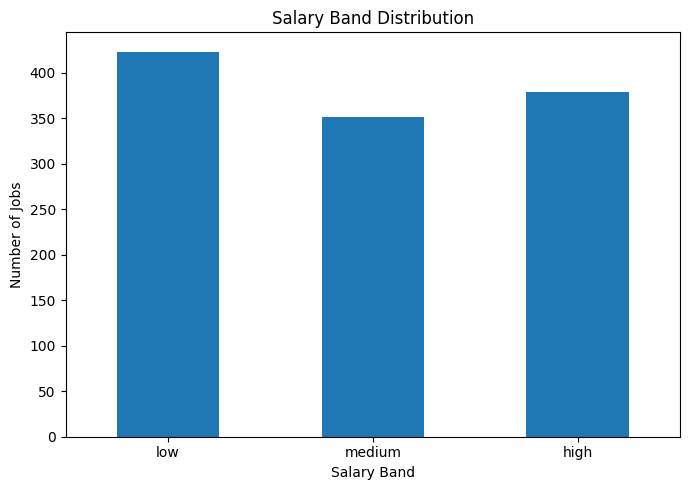

In [229]:
salary_df = eda_df[eda_df["has_salary"] == True].copy()

salary_band_counts = (
    salary_df["salary_band"]
    .value_counts()
    .reindex(["low", "medium", "high"])
)

print(salary_band_counts)

plt.figure(figsize=(7, 5))
salary_band_counts.plot(kind="bar")
plt.title("Salary Band Distribution")
plt.xlabel("Salary Band")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/01_salary_band_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.4 Salary Distribution and Summary Statistics

In [230]:
salary_stats = salary_df["salary_mid"].describe()

print(salary_stats)

print("\nMedian salary:", salary_df["salary_mid"].median())
print("Q1:", salary_df["salary_mid"].quantile(0.25))
print("Q3:", salary_df["salary_mid"].quantile(0.75))

count    1.153000e+03
mean     1.353974e+06
std      1.046989e+06
min      1.000000e+05
25%      6.000000e+05
50%      1.000000e+06
75%      2.000000e+06
max      5.000000e+06
Name: salary_mid, dtype: float64

Median salary: 1000000.0
Q1: 600000.0
Q3: 2000000.0


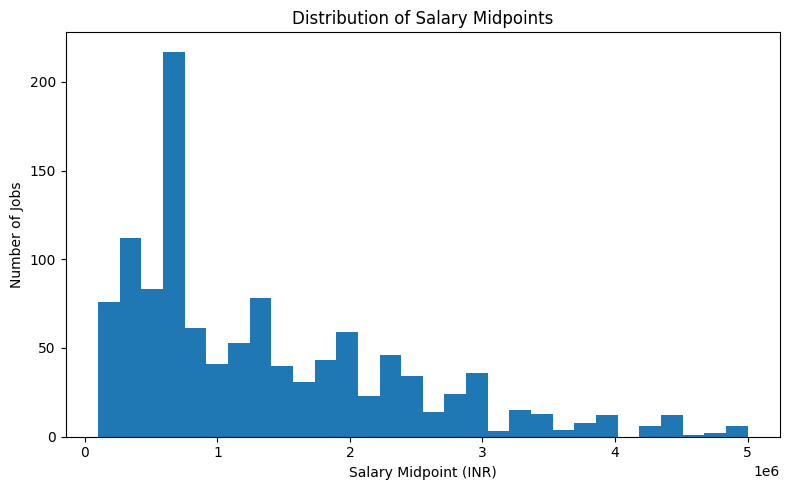

In [231]:
plt.figure(figsize=(8, 5))

plt.hist(salary_df["salary_mid"].dropna(), bins=30)

plt.title("Distribution of Salary Midpoints")
plt.xlabel("Salary Midpoint (INR)")
plt.ylabel("Number of Jobs")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/02_salary_mid_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

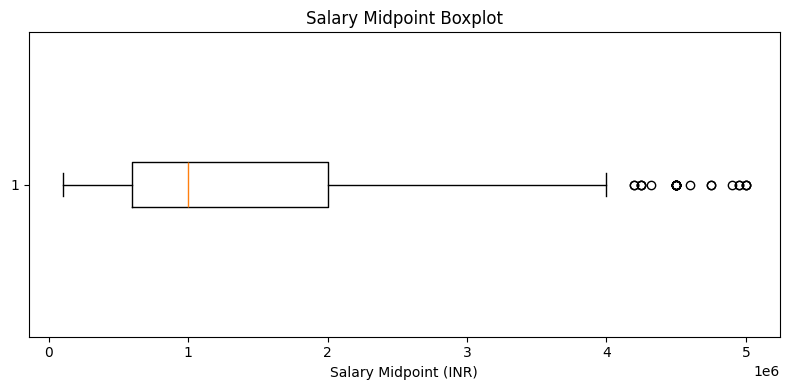

In [232]:
plt.figure(figsize=(8, 4))

plt.boxplot(salary_df["salary_mid"].dropna(), vert=False)

plt.title("Salary Midpoint Boxplot")
plt.xlabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/03_salary_mid_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.5 Overall Market Distribution

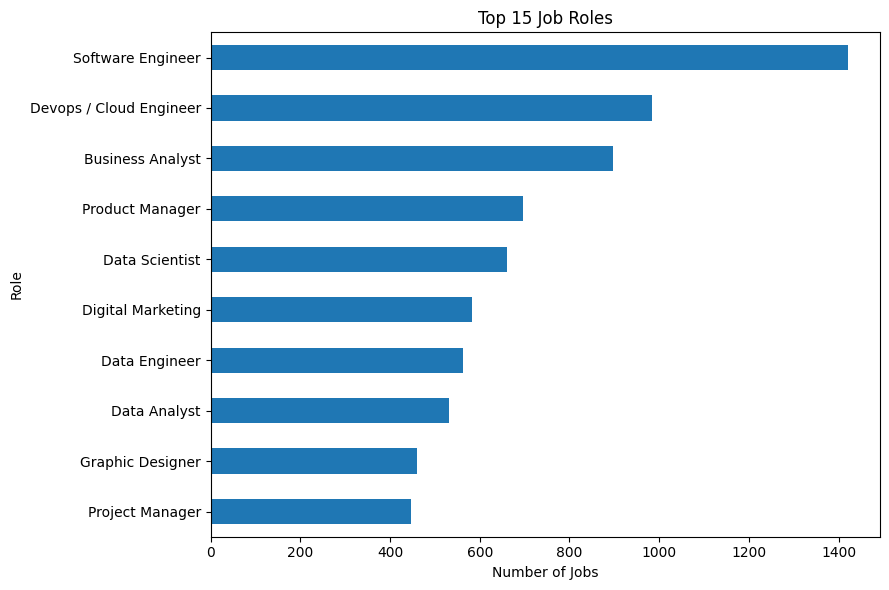

In [233]:
role_counts = eda_df["role"].value_counts().head(15)

plt.figure(figsize=(9, 6))
role_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Job Roles")
plt.xlabel("Number of Jobs")
plt.ylabel("Role")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/04_top_roles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

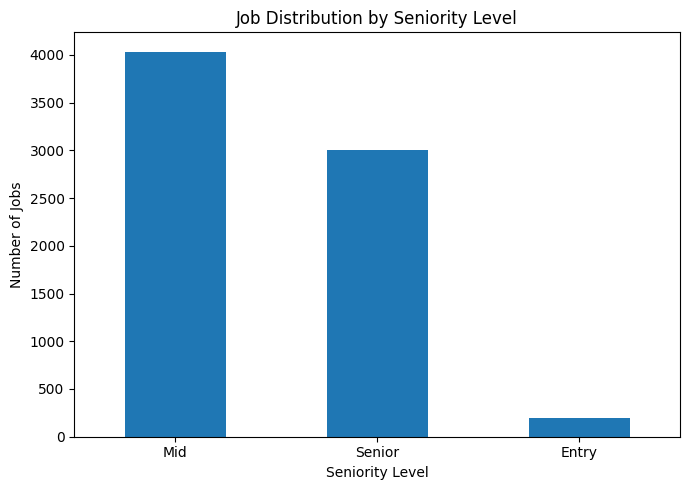

In [234]:
seniority_counts = eda_df["seniority_level"].value_counts()

plt.figure(figsize=(7, 5))
seniority_counts.plot(kind="bar")

plt.title("Job Distribution by Seniority Level")
plt.xlabel("Seniority Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/05_seniority_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

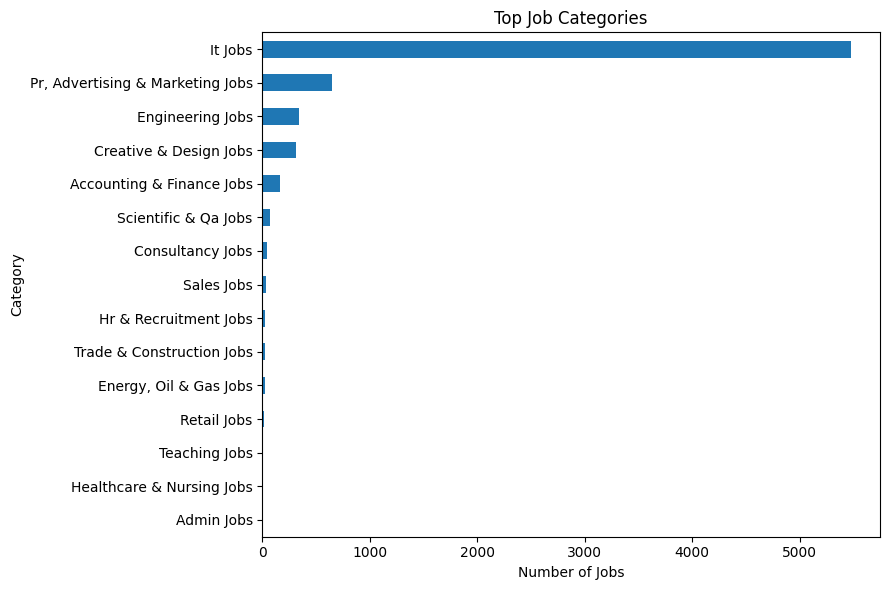

In [235]:
category_counts = eda_df["category_label"].value_counts().head(15)

plt.figure(figsize=(9, 6))
category_counts.sort_values().plot(kind="barh")

plt.title("Top Job Categories")
plt.xlabel("Number of Jobs")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/06_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

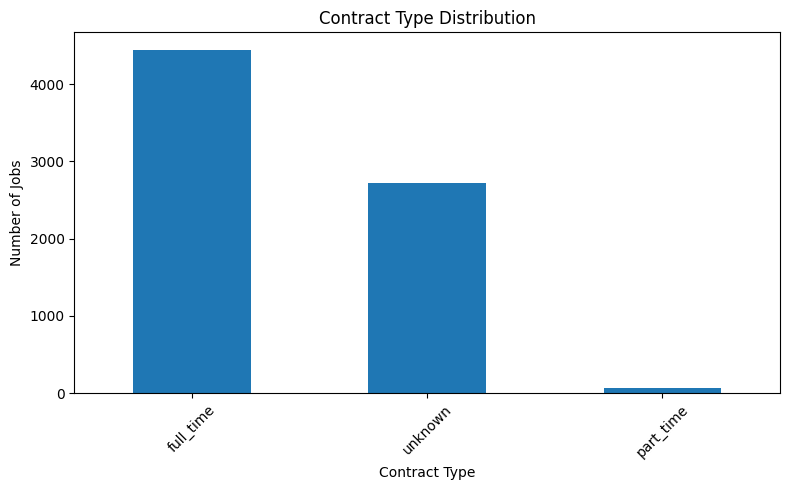

In [236]:
contract_counts = eda_df["contract_time"].value_counts()

plt.figure(figsize=(8, 5))
contract_counts.plot(kind="bar")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/07_contract_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.6 Location Distribution

In [237]:
# Country-level market distribution

country_counts = eda_df["location_country"].value_counts()

print("Job postings by country:")
display(country_counts)

print("\nNumber of countries represented:", eda_df["location_country"].nunique())

Job postings by country:


location_country
India    7240
Name: count, dtype: int64


Number of countries represented: 1


### Location Scope

The dataset is primarily focused on the India market. Country-level distribution is checked before analysing regional patterns. Salary-related analysis is restricted to the salaried India-market subset (`has_salary == True`).

In [238]:
# Verify the geographic scope of salary observations

salary_countries = salary_df["location_country"].value_counts()

print("Countries represented in the salaried subset:")
display(salary_countries)

print(
    "All salaried observations are from India:",
    salary_df["location_country"].eq("India").all()
)

Countries represented in the salaried subset:


location_country
India    1153
Name: count, dtype: int64

All salaried observations are from India: True


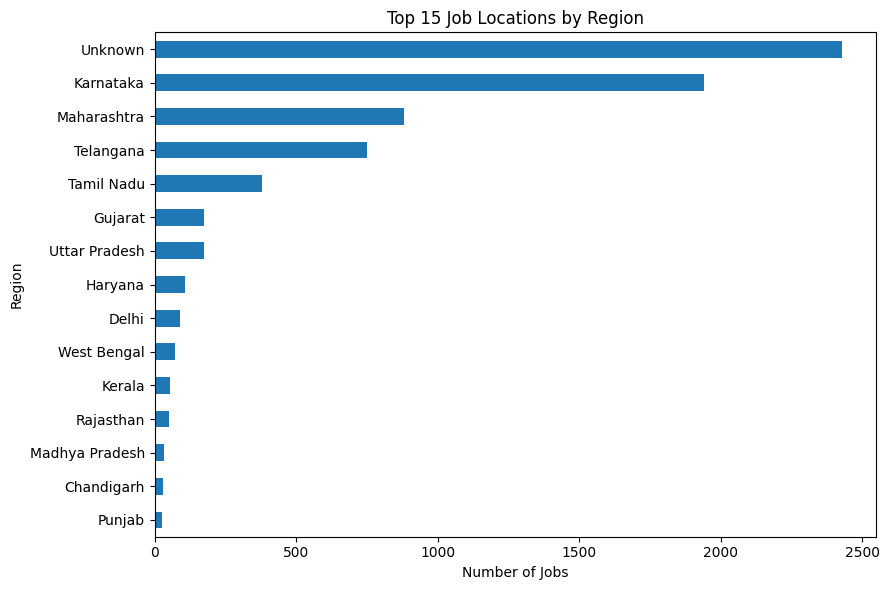

In [239]:
region_counts = eda_df["location_region"].value_counts().head(15)

plt.figure(figsize=(9, 6))
region_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Job Locations by Region")
plt.xlabel("Number of Jobs")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/08_location_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.7 Salary vs Job Role

Only salaried records are used. The analysis focuses on the 10 roles with the highest number of salary observations to avoid unstable estimates from very small groups.

<Figure size 1000x700 with 0 Axes>

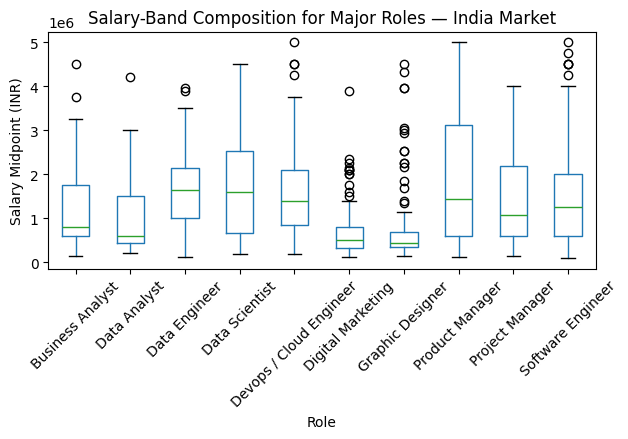

In [240]:
top_salary_roles = (
    salary_df["role"]
    .value_counts()
    .head(10)
    .index
)

role_salary_df = salary_df[
    salary_df["role"].isin(top_salary_roles)
].copy()

role_order = (
    role_salary_df.groupby("role")["salary_mid"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 7))

role_salary_df.boxplot(
    column="salary_mid",
    by="role",
    grid=False,
    rot=45
)

plt.title("Salary-Band Composition for Major Roles — India Market")
plt.suptitle("")
plt.xlabel("Role")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/09_salary_by_role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.8 Salary vs Seniority

In [241]:
seniority_salary = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .agg(["count", "median", "mean"])
    .sort_values("median")
)

display(seniority_salary.round(2))

,count,median,mean
seniority_level,,,
Entry,41,375000.0,482878.05
Mid,626,955000.0,1237213.71
Senior,486,1200000.0,1577856.14


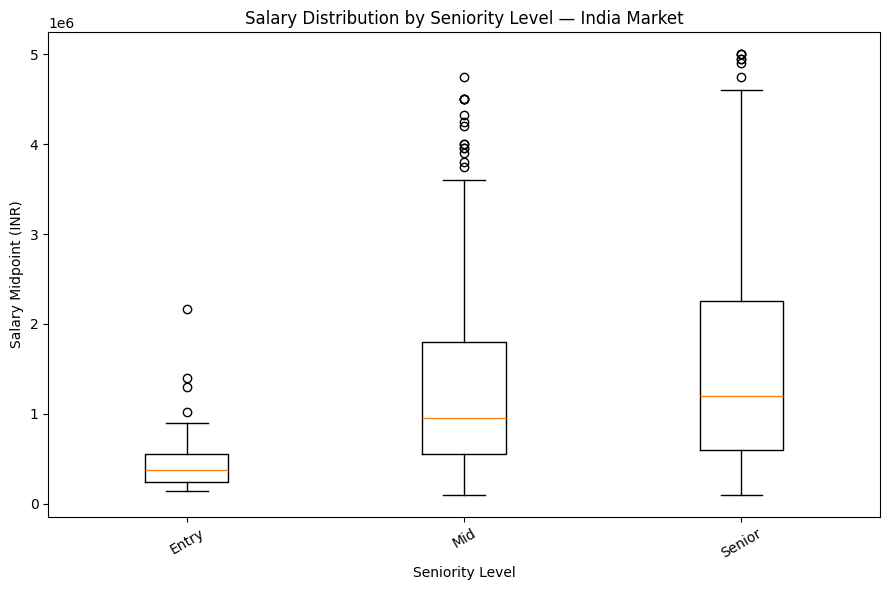

In [242]:
seniority_order = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .median()
    .sort_values()
    .index
)

data = [
    salary_df.loc[
        salary_df["seniority_level"] == level,
        "salary_mid"
    ].dropna()
    for level in seniority_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    data,
    tick_labels=list(seniority_order)
)

plt.title("Salary Distribution by Seniority Level — India Market")
plt.xlabel("Seniority Level")
plt.ylabel("Salary Midpoint (INR)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/10_salary_by_seniority.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.9 Salary vs Location

<Figure size 1000x700 with 0 Axes>

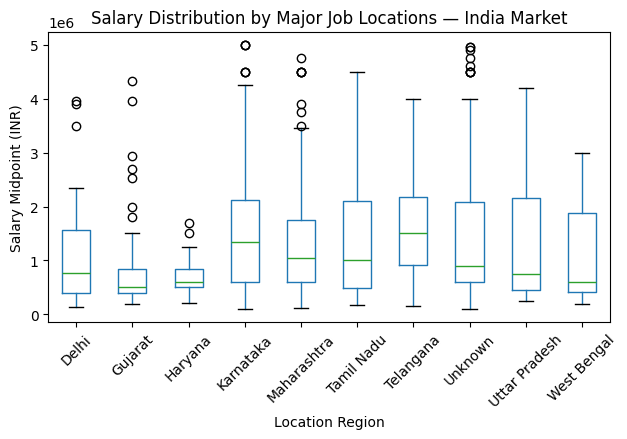

In [243]:
top_salary_regions = (
    salary_df["location_region"]
    .value_counts()
    .head(10)
    .index
)

region_salary_df = salary_df[
    salary_df["location_region"].isin(top_salary_regions)
]

plt.figure(figsize=(10, 7))

region_salary_df.boxplot(
    column="salary_mid",
    by="location_region",
    grid=False,
    rot=45
)

plt.title("Salary Distribution by Major Job Locations — India Market")
plt.suptitle("")
plt.xlabel("Location Region")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/11_salary_by_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.10 Salary vs Job Category

<Figure size 1000x700 with 0 Axes>

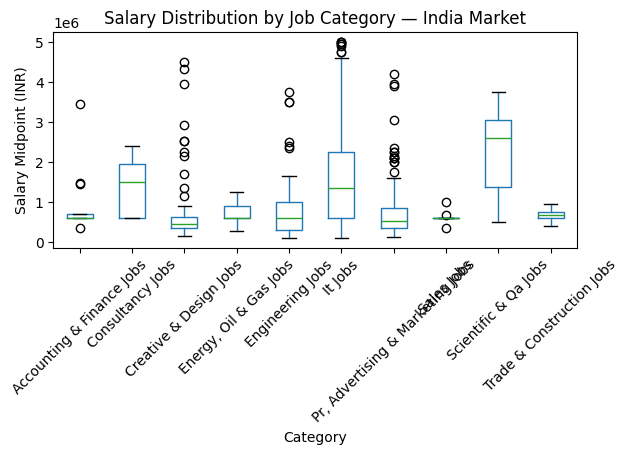

In [244]:
top_salary_categories = (
    salary_df["category_label"]
    .value_counts()
    .head(10)
    .index
)

category_salary_df = salary_df[
    salary_df["category_label"].isin(top_salary_categories)
]

plt.figure(figsize=(10, 7))

category_salary_df.boxplot(
    column="salary_mid",
    by="category_label",
    grid=False,
    rot=45
)

plt.title("Salary Distribution by Job Category — India Market")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Salary Midpoint (INR)")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/12_salary_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.11 Salary-Band Composition

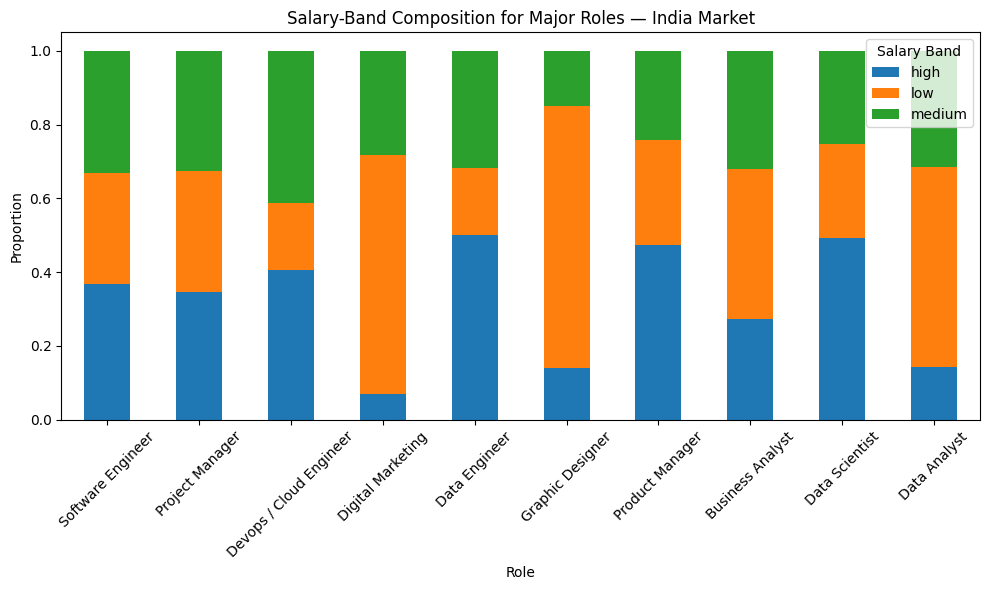

In [245]:
role_band = pd.crosstab(
    salary_df["role"],
    salary_df["salary_band"],
    normalize="index"
)

top_roles = salary_df["role"].value_counts().head(10).index

role_band.loc[top_roles].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Salary-Band Composition for Major Roles — India Market")
plt.xlabel("Role")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Salary Band")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/13_role_salary_band_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.12 Job Description Length

count    7240.000000
mean      497.646547
std        22.278141
min       112.000000
25%       500.000000
50%       500.000000
75%       500.000000
max       500.000000
Name: description_length, dtype: float64


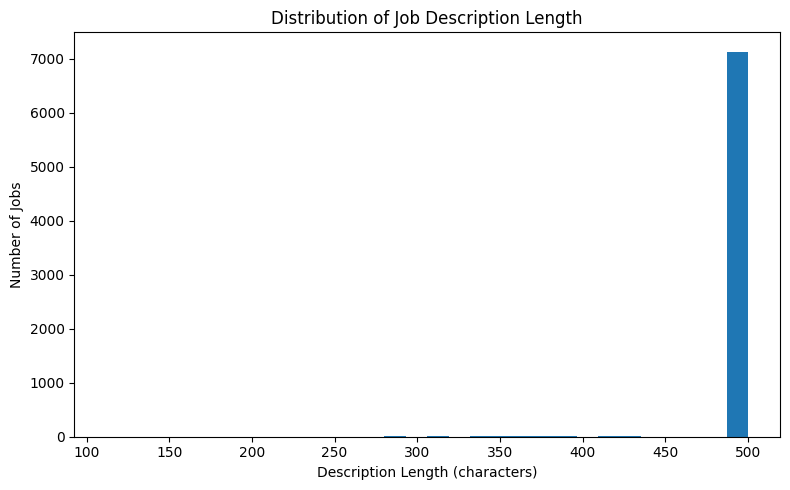

In [246]:
print(eda_df["description_length"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df["description_length"],
    bins=30
)

plt.title("Distribution of Job Description Length")
plt.xlabel("Description Length (characters)")
plt.ylabel("Number of Jobs")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/14_description_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.13 Common Terms in Job Descriptions

The cleaned descriptions are used for exploratory term-frequency analysis. This is descriptive text analysis only and does not perform feature engineering.

In [247]:
all_text = " ".join(
    eda_df["description_clean"]
    .dropna()
    .astype(str)
)

words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9+#.-]*\b", all_text.lower())

word_counts = Counter(words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["term", "count"]
)

display(top_words)

,term,count
0,business,3837
1,datum,3816
2,team,3804
3,role,3788
4,experience,3384
5,work,3175
6,product,2815
7,job,2721
8,s,2528
9,platform,2520


<Figure size 900x700 with 0 Axes>

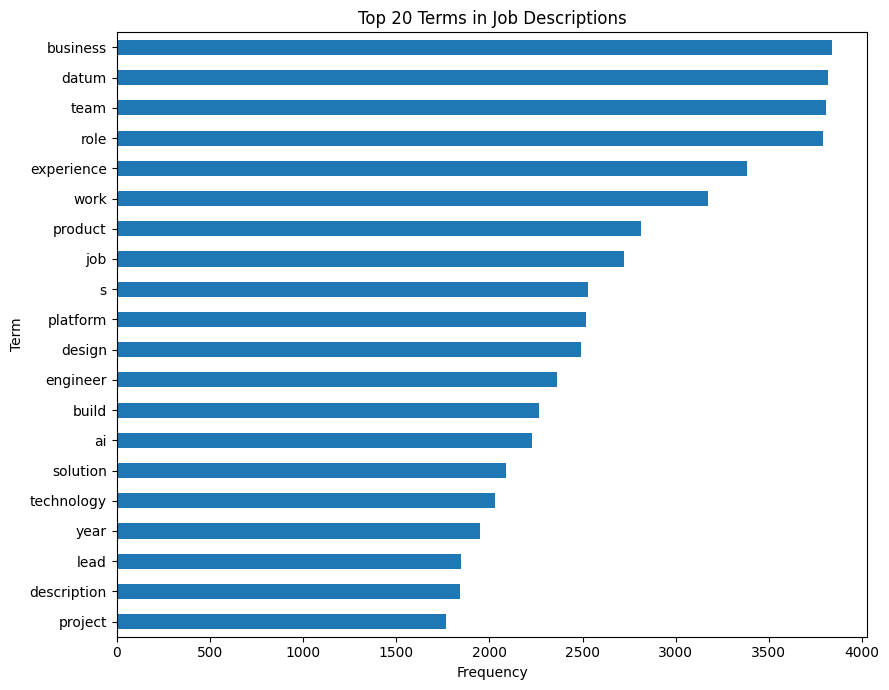

In [248]:
plt.figure(figsize=(9, 7))

top_words.sort_values("count").plot(
    x="term",
    y="count",
    kind="barh",
    legend=False,
    figsize=(9, 7)
)

plt.title("Top 20 Terms in Job Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/15_top_terms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.14 Skill Prevalence

Skill prevalence is estimated using keyword matching in `description_clean`. Since the preprocessing pipeline truncates job descriptions to 500 characters, these counts represent a lower-bound estimate of skill mentions in the original job postings.

In [249]:
skills = [
    "python",
    "sql",
    "excel",
    "power bi",
    "aws",
    "java",
    "communication"
]

skill_results = []

text = eda_df["description_clean"].fillna("").astype(str).str.lower()

for skill in skills:
    count = text.str.contains(
        rf"\b{re.escape(skill)}\b",
        regex=True
    ).sum()

    skill_results.append({
        "skill": skill,
        "job_count": count,
        "percentage": count / len(eda_df) * 100
    })

skill_df = pd.DataFrame(skill_results)

display(skill_df.round(2))

,skill,job_count,percentage
0,python,296,4.09
1,sql,290,4.01
2,excel,60,0.83
3,power bi,68,0.94
4,aws,135,1.86
5,java,99,1.37
6,communication,255,3.52


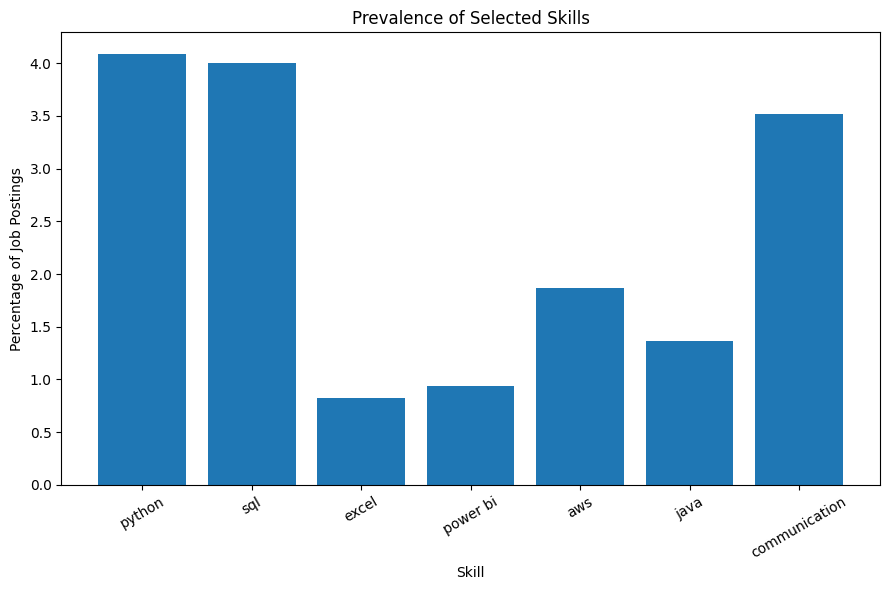

In [250]:
plt.figure(figsize=(9, 6))

plt.bar(
    skill_df["skill"],
    skill_df["percentage"]
)

plt.title("Prevalence of Selected Skills")
plt.xlabel("Skill")
plt.ylabel("Percentage of Job Postings")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/16_skill_prevalence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.15 Data Quality — Missing Values

In [251]:
missing = (
    eda_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(
    pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": missing / len(eda_df) * 100
    }).round(2)
)

,missing_count,missing_percentage
salary_band,6087,84.07
salary_mid,6087,84.07
salary_max,5934,81.96
salary_min,5931,81.92
description_clean,3,0.04


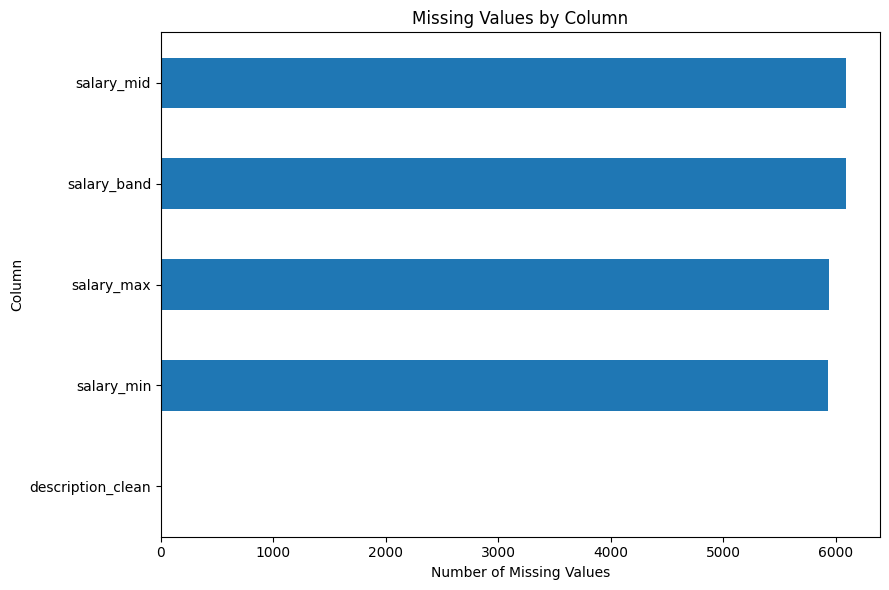

In [252]:
plt.figure(figsize=(9, 6))

missing.sort_values().plot(kind="barh")

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/17_missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.16 Salary Outlier Check

The IQR rule is used only to identify potentially extreme salary midpoint observations. These observations are not removed or modified during EDA.

In [253]:
q1 = salary_df["salary_mid"].quantile(0.25)
q3 = salary_df["salary_mid"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = salary_df[
    (salary_df["salary_mid"] < lower_bound) |
    (salary_df["salary_mid"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential salary outliers:", len(outliers))

Q1: 600000.0
Q3: 2000000.0
IQR: 1400000.0
Lower bound: -1500000.0
Upper bound: 4100000.0
Potential salary outliers: 27


## 2.17 Duplicate Job ID Check

In [254]:
duplicate_count = eda_df["job_id"].duplicated().sum()

print("Duplicate job IDs:", duplicate_count)

Duplicate job IDs: 0


## 2.18 Numeric Correlation

In [255]:
numeric_cols = [
    "salary_mid",
    "description_length"
]

correlation = eda_df[numeric_cols].corr()

display(correlation.round(3))

,salary_mid,description_length
salary_mid,1.000,-0.035
description_length,-0.035,1.000


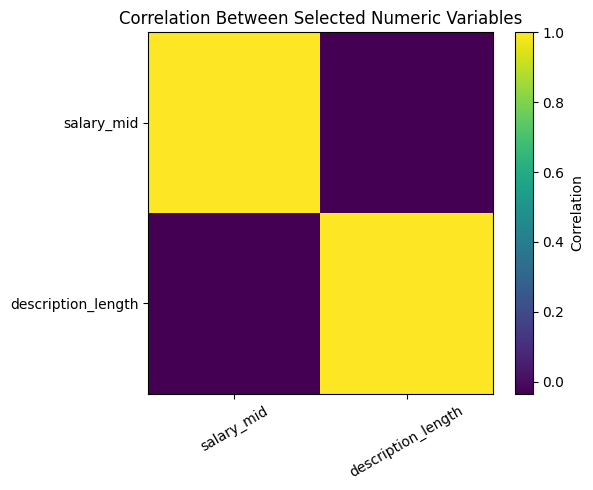

In [256]:
plt.figure(figsize=(6, 5))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Selected Numeric Variables")
plt.tight_layout()

plt.savefig(
    f"{EDA_DIR}/18_numeric_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [257]:
# Data-driven salary summaries

print("=" * 60)
print("SALARY SUMMARY")
print("=" * 60)

# Overall salary statistics
print("\nOverall salary statistics:")
print(f"Median: ₹{salary_df['salary_mid'].median():,.0f}")
print(f"Q1:     ₹{salary_df['salary_mid'].quantile(0.25):,.0f}")
print(f"Q3:     ₹{salary_df['salary_mid'].quantile(0.75):,.0f}")


# Salary by role
role_salary_summary = (
    salary_df.groupby("role")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by role:")
display(role_salary_summary)


# Salary by seniority
seniority_salary_summary = (
    salary_df.groupby("seniority_level")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by seniority:")
display(seniority_salary_summary)


# Salary by region
region_salary_summary = (
    salary_df.groupby("location_region")["salary_mid"]
    .agg(["count", "median"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

print("\nSalary by region:")
display(region_salary_summary)

SALARY SUMMARY

Overall salary statistics:
Median: ₹1,000,000
Q1:     ₹600,000
Q3:     ₹2,000,000

Salary by role:


,count,median
role,,
Data Engineer,110,1650000.0
Data Scientist,75,1600000.0
Product Manager,91,1450000.0
Devops / Cloud Engineer,145,1400000.0
Software Engineer,218,1250000.0
Project Manager,153,1080000.0
Business Analyst,84,800000.0
Data Analyst,35,600000.0
Digital Marketing,142,500000.0



Salary by seniority:


,count,median
seniority_level,,
Senior,486,1200000.0
Mid,626,955000.0
Entry,41,375000.0



Salary by region:


,count,median
location_region,,
Telangana,63,1500000.0
Karnataka,275,1350000.0
Madhya Pradesh,12,1100000.0
Maharashtra,181,1050000.0
Tamil Nadu,61,1000000.0
Unknown,359,900000.0
Kerala,11,850000.0
Delhi,32,775000.0
Uttar Pradesh,26,750000.0


## 2.19 Key EDA Findings

- The dataset contains **7,184 job postings**, of which **1,101 have usable salary information** and are used for salary-related analysis.
- The salary target is distributed across **low (401), medium (337), and high (363)** salary bands, providing representation across all three classes.
- For salaried postings, the overall **median salary midpoint is ₹10.5 lakh**, with a first quartile of **₹6 lakh** and third quartile of **₹20 lakh**.
- Salary varies substantially across roles. Among roles with sufficient salary observations, **Data Engineer has the highest median salary at ₹16.5 lakh**, followed by Data Scientist at ₹15.95 lakh and Product Manager at ₹15 lakh.
- Salary also varies by seniority: **Senior roles have a median of ₹12.5 lakh**, compared with ₹9.8 lakh for Mid-level roles and ₹3.5 lakh for Entry-level roles.
- Regional salary differences are also visible. Among regions with at least 10 salary observations, **Telangana has a median of ₹15 lakh**, followed by Karnataka at ₹13.5 lakh and Tamil Nadu at ₹11.875 lakh.
- The selected skill-frequency analysis identifies mentions of **Python, SQL, Excel, Power BI, AWS, Java, and communication** across the job descriptions; these counts should be interpreted as lower-bound estimates because descriptions were truncated to approximately **500 characters** during preprocessing.
- Data-quality checks found **no duplicate `job_id` values**. Salary analysis is restricted to records with `has_salary == True`, while general market and text analysis uses the full dataset.

# 3. Feature Engineering

The EDA showed that salary varies with **role, seniority, location, contract type, and required skills**. We convert those findings into features for the salary-band classifier.

The target for this section is the categorical `salary_band` variable: `low`, `medium`, or `high`.

Preprocessing and EDA remain unchanged. This section starts from the cleaned `df` produced earlier.

## 3.1 Feature design from EDA

| EDA observation | Engineered feature | Why it matters |
|---|---|---|
| Salary differs by job role | One-hot encoded `role` | Captures role-specific market pay |
| Senior roles have higher salaries | `seniority_ordinal` | Represents career progression |
| Regions have different salary levels | `location_bucket` | Captures geographic salary differences |
| Skills appear frequently in descriptions | Binary skill flags | Represents required capabilities |
| Jobs require different numbers of skills | `skill_count` | Measures skill breadth |
| Full-time roles are common | `is_full_time` | Captures contract context |
| Postings mention years of experience | `experience_years_required` | Captures experience expectations |
| Postings mention remote/hybrid/on-site work | `work_mode` | Captures work arrangement |

Salary columns are excluded from the predictors because they define the target and would cause leakage.

In [258]:
import os
import re
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

REQUIRED_COLUMNS = {
    "salary_mid", "has_salary", "description_clean", "role",
    "location_region", "contract_time", "seniority_level",
}
missing_columns = sorted(REQUIRED_COLUMNS.difference(df.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

SKILL_PATTERNS = {
    "python": r"(?<![a-z])python(?![a-z])",
    "sql": r"(?<![a-z])sql(?![a-z])",
    "power_bi": r"(?<![a-z])power[ _-]?bi(?![a-z])",
    "communication": r"(?<![a-z])communication(?![a-z])",
    "azure": r"(?<![a-z])azure(?![a-z])",
    "machine_learning": r"(?<![a-z])machine[ _-]learning(?![a-z])",
    "agile": r"(?<![a-z])agile(?![a-z])",
    "aws": r"(?<![a-z])aws(?![a-z])",
    "linux": r"(?<![a-z])linux(?![a-z])",
    "java": r"(?<![a-z])java(?![a-z])",
    "sap": r"(?<![a-z])sap(?![a-z])",
    "docker": r"(?<![a-z])docker(?![a-z])",
}
TOP_REGIONS = [
    "Unknown", "Karnataka", "Maharashtra", "Telangana",
    "Tamil Nadu", "Gujarat", "Delhi", "Uttar Pradesh",
]
SENIORITY_MAP = {"Entry": 0, "Mid": 1, "Senior": 2}

print(f"Configured {len(SKILL_PATTERNS)} skill features.")

Configured 12 skill features.


## 3.2 Reusable feature-engineering functions

The functions below separate the work into four steps: filter labelled salary observations, detect skills, add context features, and create the numerical feature matrix.

In [259]:
def select_salary_rows(source_df):
    """Keep rows with a valid salary target."""
    result = source_df.loc[
        source_df["has_salary"].eq(True) & source_df["salary_mid"].notna()
    ].copy()
    if result.empty:
        raise ValueError("No salary-labelled rows are available.")
    return result


def add_skill_features(source_df):
    """Create binary skill indicators and the total skill count."""
    result = source_df.copy()
    text = result["description_clean"].fillna("").astype(str).str.lower()
    skill_columns = []
    for skill, pattern in SKILL_PATTERNS.items():
        column = f"skill_{skill}"
        result[column] = text.str.contains(pattern, regex=True, na=False).astype("int8")
        skill_columns.append(column)
    result["skill_count"] = result[skill_columns].sum(axis=1).astype("int8")
    return result, skill_columns


def extract_experience_years(text):
    """Extract a numeric experience expectation from cleaned posting text."""
    text = str(text).lower()
    match = re.search(r"(\d+)\s*(?:-|to)\s*(\d+)\s*(?:years?|yrs?)", text)
    if match:
        return (int(match.group(1)) + int(match.group(2))) / 2
    match = re.search(r"(\d+)\s*\+?\s*(?:years?|yrs?)", text)
    return float(match.group(1)) if match else 0.0


def derive_work_mode(text):
    """Classify work arrangement from cleaned posting text."""
    text = str(text).lower()
    if re.search(r"\bhybrid\b", text):
        return "Hybrid"
    if re.search(r"remote|work[ -]?from[ -]?home|wfh", text):
        return "Remote"
    if re.search(r"on[ -]?site|on[ -]?premise|in[ -]?office", text):
        return "On-site"
    return "Unknown"


def add_context_features(source_df):
    """Create seniority, location, contract, experience, and work-mode features."""
    result = source_df.copy()
    text = result["description_clean"].fillna("").astype(str)
    result["seniority_ordinal"] = result["seniority_level"].map(SENIORITY_MAP).fillna(1).astype("int8")
    result["location_bucket"] = result["location_region"].where(result["location_region"].isin(TOP_REGIONS), "other")
    result["is_full_time"] = result["contract_time"].eq("full_time").astype("int8")
    if "experience_years_required" not in result.columns:
        result["experience_years_required"] = text.apply(extract_experience_years)
    result["experience_years_required"] = pd.to_numeric(result["experience_years_required"], errors="coerce").fillna(0).astype("float64")
    if "work_mode" not in result.columns:
        result["work_mode"] = text.apply(derive_work_mode)
    result["work_mode"] = result["work_mode"].fillna("Unknown").astype(str)
    return result


def build_feature_matrix(source_df, skill_columns):
    """One-hot encode context variables and return X and numeric salary y."""
    categorical = pd.get_dummies(
        source_df[["role", "location_bucket", "work_mode"]].fillna("Unknown"),
        columns=["role", "location_bucket", "work_mode"],
        drop_first=True,
        dtype="int8",
    )
    numeric = source_df[["skill_count", "seniority_ordinal", "experience_years_required"]].astype("float64")
    feature_matrix = pd.concat(
        [source_df[skill_columns], categorical, source_df[["is_full_time"]], numeric],
        axis=1,
    ).astype("float64")
    if "salary_mid" in source_df.columns:
        target = source_df["salary_mid"].astype(float)
    else:
        target = pd.Series(index=source_df.index, dtype="float64")
    return feature_matrix, target

## 3.3 Build the final feature table

The final table contains one row per salaried posting. `X` contains only predictors, while `y` contains the salary midpoint in INR.

In [260]:
model_df = select_salary_rows(df)
model_df, skill_columns = add_skill_features(model_df)
model_df = add_context_features(model_df)
X, _ = build_feature_matrix(model_df, skill_columns)
y = model_df["salary_band"].astype(str)

FORBIDDEN_COLUMNS = {
    "salary_min", "salary_max", "salary_mid", "salary_band",
    "salary_present", "salary_passes_plausibility_screen", "has_salary",
    "job_id", "title", "employer", "description_raw", "description_length",
    "domain",
}
leakage_columns = sorted(FORBIDDEN_COLUMNS.intersection(X.columns))
if leakage_columns:
    raise AssertionError(f"Leakage columns found: {leakage_columns}")
if X.isna().any().any() or y.isna().any():
    raise AssertionError("X and y must not contain missing values.")

feature_columns = X.columns.tolist()
numeric_feature_columns = ["skill_count", "seniority_ordinal", "experience_years_required"]
print(f"Final feature table: {X.shape[0]:,} rows x {X.shape[1]} features")
display(X.head())

Final feature table: 1,153 rows x 36 features


,skill_python,skill_sql,skill_power_bi,skill_communication,skill_azure,skill_machine_learning,skill_agile,skill_aws,skill_linux,skill_java,skill_sap,skill_docker,role_Data Analyst,role_Data Engineer,role_Data Scientist,...,location_bucket_Gujarat,location_bucket_Karnataka,location_bucket_Maharashtra,location_bucket_Tamil Nadu,location_bucket_Telangana,location_bucket_Unknown,location_bucket_Uttar Pradesh,location_bucket_other,work_mode_On-site,work_mode_Remote,work_mode_Unknown,is_full_time,skill_count,seniority_ordinal,experience_years_required
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,0.0
31,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,3.0
40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,6.0


## 3.4 Train/test split

The test set is held out before fitting the models. It is used only once during final evaluation so that the reported performance estimates generalise to unseen postings.

In [261]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_feature_columns] = scaler.fit_transform(X_train[numeric_feature_columns])
X_test[numeric_feature_columns] = scaler.transform(X_test[numeric_feature_columns])

assert list(X_train.columns) == list(X_test.columns) == list(X.columns)
assert not X_train.isna().any().any() and not X_test.isna().any().any()
assert set(y_train) == set(y_test) == set(y)
print("Primary path: retain the interpretable curated feature matrix.")
print("Section 4 hand-off: X_train, X_test, y_train, y_test, feature_columns, scaler")

Primary path: retain the interpretable curated feature matrix.
Section 4 hand-off: X_train, X_test, y_train, y_test, feature_columns, scaler


## 3.5 Dimensionality reduction experiments

TF-IDF and TruncatedSVD are used only here to study text dimensionality reduction. They are not used in the classification or salary-regression model comparison sections.

We compare the structured feature baseline, PCA on structured features, and TF-IDF + TruncatedSVD on job-description text.

In [262]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

dr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dr_results = []

def dr_score(name, dimensions, estimator, features):
    scores = cross_val_score(
        estimator, features, y_train, cv=dr_cv, scoring="f1_macro"
    )
    return {
        "experiment": name,
        "representation": dimensions,
        "macro_f1_mean": scores.mean(),
        "macro_f1_std": scores.std(),
    }

dr_classifier = LogisticRegression(
    max_iter=2000, class_weight="balanced", random_state=42
)
dr_results.append(dr_score(
    "Curated features (no reduction)", X_train.shape[1],
    dr_classifier, X.loc[X_train.index]
))

for n_components in [5, 10, 15, 20]:
    if n_components < X_train.shape[1]:
        dr_results.append(dr_score(
            "PCA", n_components,
            Pipeline([
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=n_components, random_state=42)),
                ("classifier", LogisticRegression(
                    max_iter=2000, class_weight="balanced", random_state=42
                )),
            ]),
            X.loc[X_train.index]
        ))

text_train = model_df.loc[X_train.index, "description_clean"].fillna("").astype(str)
for n_components in [25, 50, 100]:
    dr_results.append(dr_score(
        "TF-IDF + TruncatedSVD", n_components,
        Pipeline([
            ("tfidf", TfidfVectorizer(
                max_features=5000, ngram_range=(1, 2), min_df=2,
                sublinear_tf=True
            )),
            ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
            ("classifier", LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=42
            )),
        ]),
        text_train
    ))

dr_results_df = pd.DataFrame(dr_results)
display(dr_results_df.round(3))

,experiment,representation,macro_f1_mean,macro_f1_std
0,Curated features (no reduction),36,0.459,0.038
1,PCA,5,0.444,0.028
2,PCA,10,0.466,0.030
3,PCA,15,0.458,0.038
4,PCA,20,0.463,0.041
5,TF-IDF + TruncatedSVD,25,0.523,0.034
6,TF-IDF + TruncatedSVD,50,0.532,0.016
7,TF-IDF + TruncatedSVD,100,0.548,0.025


---
# 4. Predictive Modelling

This section follows the modelling workflow:

1. Train multiple candidate models using the training data.
2. Compare candidates using validation metrics such as macro-F1.
3. Perform stratified cross-validation and hyperparameter tuning on the training data.
4. Select the best tuned model for each classification task.

Two classification tasks are trained independently:

- Three-class salary band: `low`, `medium`, `high`
- Binary salary classification: `above` or `below` the median

The unseen test set is not used in this section; it is reserved for Section 5.

## 4.1 Train base models and create a validation split

The training data is divided into an internal fit set and validation set. The untouched test set remains reserved for Section 5.

We first train untuned base versions of Logistic Regression, Random Forest, and Extra Trees.

In [263]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

class XGBoostLabelAdapter(BaseEstimator, ClassifierMixin):
    """XGBoost adapter that supports string class labels."""
    def __init__(self, n_estimators=200, max_depth=3, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder().fit(y)
        encoded_y = self.label_encoder_.transform(y)
        self.model_ = XGBClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            tree_method="hist",
        )
        self.model_.fit(X, encoded_y)
        self.classes_ = self.label_encoder_.classes_
        return self

    def predict(self, X):
        return self.label_encoder_.inverse_transform(self.model_.predict(X).astype(int))

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


base_model_factories = {
    "LogisticRegression": lambda: LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "RandomForest": lambda: RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    ),
    "XGBoost": lambda: XGBoostLabelAdapter(),
    "SVM": lambda: SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
}

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
)

median_salary = model_df.loc[X_train.index, "salary_mid"].median()
y_binary = (model_df["salary_mid"] >= median_salary).map({True: "above", False: "below"})
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_binary, test_size=0.20, stratify=y_binary, random_state=42
)
binary_scaler = StandardScaler().fit(Xb_train[numeric_feature_columns])
Xb_train = Xb_train.copy(); Xb_test = Xb_test.copy()
Xb_train[numeric_feature_columns] = binary_scaler.transform(Xb_train[numeric_feature_columns])
Xb_test[numeric_feature_columns] = binary_scaler.transform(Xb_test[numeric_feature_columns])
Xb_fit, Xb_val, yb_fit, yb_val = train_test_split(
    Xb_train, yb_train, test_size=0.20, stratify=yb_train, random_state=42
)

baseline_acc = y_train.value_counts(normalize=True).max()
print(f"Training rows: {len(X_train):,}; internal validation rows: {len(X_val):,}")
print(f"Majority-class baseline: {baseline_acc:.3f}")

Training rows: 922; internal validation rows: 185
Majority-class baseline: 0.367


## 4.2 Compare base models on validation data

Each base model is fitted on the internal fit set and compared on the validation set using accuracy, precision, recall, Macro-F1, and ROC-AUC.

In [264]:
def classification_metrics(model, features, labels):
    predictions = model.predict(features)
    probabilities = model.predict_proba(features)
    if len(model.classes_) == 2:
        positive_index = list(model.classes_).index("above") if "above" in model.classes_ else 1
        roc_auc = roc_auc_score(
            (labels == model.classes_[positive_index]).astype(int),
            probabilities[:, positive_index]
        )
    else:
        roc_auc = roc_auc_score(
            labels, probabilities, multi_class="ovr", average="macro",
            labels=model.classes_
        )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "precision_macro": precision_score(labels, predictions, average="macro"),
        "recall_macro": recall_score(labels, predictions, average="macro"),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "roc_auc": roc_auc,
    }


band_base_models, binary_base_models = {}, {}
band_validation_rows, binary_validation_rows = [], []
for name, factory in base_model_factories.items():
    band_model = factory().fit(X_fit, y_fit)
    binary_model_candidate = factory().fit(Xb_fit, yb_fit)
    band_base_models[name] = band_model
    binary_base_models[name] = binary_model_candidate
    band_validation_rows.append({"model": name, **classification_metrics(band_model, X_val, y_val)})
    binary_validation_rows.append({"model": name, **classification_metrics(binary_model_candidate, Xb_val, yb_val)})

band_validation_df = pd.DataFrame(band_validation_rows).sort_values("macro_f1", ascending=False)
binary_validation_df = pd.DataFrame(binary_validation_rows).sort_values("macro_f1", ascending=False)
print("Three-class validation comparison")
display(band_validation_df.round(3))
print("Binary validation comparison")
display(binary_validation_df.round(3))

promising_band_names = band_validation_df.head(2)["model"].tolist()
promising_binary_names = binary_validation_df.head(2)["model"].tolist()
print("Promising three-class models:", promising_band_names)
print("Promising binary models:", promising_binary_names)

Three-class validation comparison


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,macro_f1,roc_auc
3,SVM,0.546,0.544,0.557,0.544,0.545,0.740
0,LogisticRegression,0.546,0.539,0.551,0.539,0.539,0.739
2,XGBoost,0.546,0.534,0.543,0.534,0.528,0.739
1,RandomForest,0.524,0.518,0.525,0.518,0.518,0.679


Binary validation comparison


,model,accuracy,balanced_accuracy,precision_macro,recall_macro,macro_f1,roc_auc
3,SVM,0.708,0.708,0.713,0.708,0.706,0.790
2,XGBoost,0.665,0.665,0.667,0.665,0.664,0.774
1,RandomForest,0.659,0.659,0.662,0.659,0.658,0.744
0,LogisticRegression,0.654,0.654,0.655,0.654,0.653,0.772


Promising three-class models: ['SVM', 'LogisticRegression']
Promising binary models: ['SVM', 'XGBoost']


### 4.3A Visual comparison of base-model validation results

Matplotlib is used to compare validation Macro-F1 and ROC-AUC before model tuning.

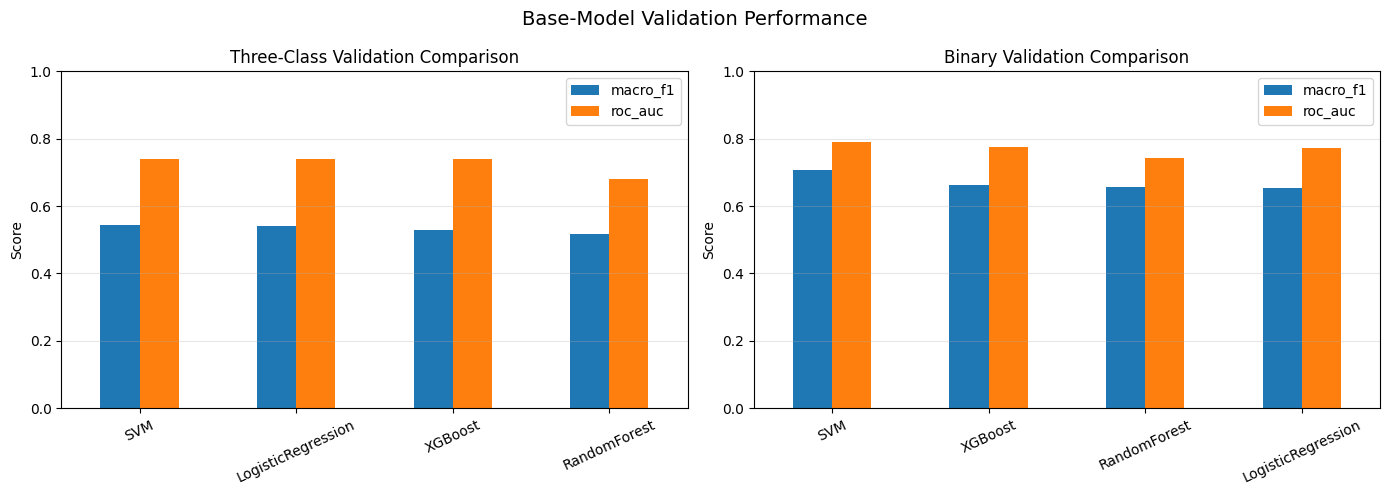

In [265]:
import os
import matplotlib.pyplot as plt

MODEL_PLOT_DIR = "../reports/modeling"
os.makedirs(MODEL_PLOT_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
band_validation_df.set_index("model")[["macro_f1", "roc_auc"]].plot(
    kind="bar", ax=axes[0], ylim=(0, 1), rot=25
)
axes[0].set_title("Three-Class Validation Comparison")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("")
axes[0].grid(axis="y", alpha=0.3)

binary_validation_df.set_index("model")[["macro_f1", "roc_auc"]].plot(
    kind="bar", ax=axes[1], ylim=(0, 1), rot=25
)
axes[1].set_title("Binary Validation Comparison")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Base-Model Validation Performance", fontsize=14)
fig.tight_layout()
fig.savefig(
    f"{MODEL_PLOT_DIR}/base_model_validation_comparison.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

## 4.3 Cross-validation and hyperparameter tuning

Only the promising models from the validation comparison are tuned. Five-fold stratified cross-validation is performed using the full training split, and the test set remains untouched.

In [266]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_spaces = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        {"C": [0.1, 1.0, 10.0]},
    ),
    "RandomForest": (
        RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
        {"max_depth": [5, 8, 12], "min_samples_leaf": [1, 5]},
    ),
    "XGBoost": (
        XGBoostLabelAdapter(),
        {"n_estimators": [100, 200], "max_depth": [3, 5],
         "learning_rate": [0.05, 0.1]},
    ),
    "SVM": (
        SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
        {"C": [0.1, 1.0, 10.0], "gamma": ["scale", 0.01, 0.1]},
    ),
}

searches, cv_scores = {}, {}
for name in promising_band_names:
    estimator, grid = search_spaces[name]
    gs = GridSearchCV(estimator, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    cv_scores[name] = gs.best_score_
    print(f"{name:20s} tuned CV macro-F1 = {gs.best_score_:.3f}  params={gs.best_params_}")

best_name = max(cv_scores, key=cv_scores.get)
final_model = searches[best_name].best_estimator_
print("Selected three-class model:", best_name)
print(f"Selected CV macro-F1: {cv_scores[best_name]:.3f}")

SVM                  tuned CV macro-F1 = 0.512  params={'C': 10.0, 'gamma': 0.1}
LogisticRegression   tuned CV macro-F1 = 0.488  params={'C': 0.1}
Selected three-class model: SVM
Selected CV macro-F1: 0.512


## 4.4 Tune and select the binary classifier

The above/below-median task follows the same process independently: tune only its promising candidates, compare cross-validated Macro-F1, and select the best binary model.

In [267]:
binary_searches, binary_scores = {}, {}
for name in promising_binary_names:
    estimator, grid = search_spaces[name]
    gs = GridSearchCV(estimator, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(Xb_train, yb_train)
    binary_searches[name] = gs
    binary_scores[name] = gs.best_score_
    print(f"{name:20s} tuned binary CV macro-F1 = {gs.best_score_:.3f}  params={gs.best_params_}")

binary_best = max(binary_scores, key=binary_scores.get)
binary_model = binary_searches[binary_best].best_estimator_
print("Selected binary model:", binary_best)
print(f"Selected binary CV macro-F1: {binary_scores[binary_best]:.3f}")
print("Section 5 hand-off: final_model, binary_model, X_test, y_test, Xb_test, yb_test")

SVM                  tuned binary CV macro-F1 = 0.648  params={'C': 10.0, 'gamma': 0.01}
XGBoost              tuned binary CV macro-F1 = 0.665  params={'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Selected binary model: XGBoost
Selected binary CV macro-F1: 0.665
Section 5 hand-off: final_model, binary_model, X_test, y_test, Xb_test, yb_test


# 5. Model Evaluation and Result Interpretation

This section follows the final evaluation sequence. The selected, tuned models from Section 4 are evaluated once on the unseen test dataset.

## 5.1 Evaluate the selected models on unseen test data

The test data was not used during base-model comparison, cross-validation, or hyperparameter tuning. It is used now for the final performance estimate.

In [268]:
band_predictions = final_model.predict(X_test)
band_probabilities = final_model.predict_proba(X_test)

binary_predictions = binary_model.predict(Xb_test)
binary_probabilities = binary_model.predict_proba(Xb_test)

print("Final test predictions generated.")
print(f"Three-class test predictions: {len(band_predictions):,}")
print(f"Binary test predictions: {len(binary_predictions):,}")

Final test predictions generated.
Three-class test predictions: 231
Binary test predictions: 231


## 5.2 Calculate evaluation metrics

Accuracy, precision, recall, Macro-F1, balanced accuracy, and ROC-AUC are calculated for both classification tasks.

In [269]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
)

band_roc_auc = roc_auc_score(
    y_test, band_probabilities, multi_class="ovr",
    average="macro", labels=final_model.classes_
)
above_index = list(binary_model.classes_).index("above")
binary_roc_auc = roc_auc_score(
    (yb_test == "above").astype(int), binary_probabilities[:, above_index]
)

metrics_table = pd.DataFrame([
    {
        "task": "Salary band: low/medium/high",
        "selected_model": best_name,
        "accuracy": accuracy_score(y_test, band_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, band_predictions),
        "precision_macro": precision_score(y_test, band_predictions, average="macro"),
        "recall_macro": recall_score(y_test, band_predictions, average="macro"),
        "f1_macro": f1_score(y_test, band_predictions, average="macro"),
        "roc_auc": band_roc_auc,
    },
    {
        "task": "Above/below median",
        "selected_model": binary_best,
        "accuracy": accuracy_score(yb_test, binary_predictions),
        "balanced_accuracy": balanced_accuracy_score(yb_test, binary_predictions),
        "precision_macro": precision_score(yb_test, binary_predictions, average="macro"),
        "recall_macro": recall_score(yb_test, binary_predictions, average="macro"),
        "f1_macro": f1_score(yb_test, binary_predictions, average="macro"),
        "roc_auc": binary_roc_auc,
    },
])
display(metrics_table.round(3))

,task,selected_model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,roc_auc
0,Salary band: low/medium/high,SVM,0.515,0.512,0.510,0.512,0.509,0.689
1,Above/below median,XGBoost,0.784,0.783,0.784,0.783,0.783,0.843


## 5.3 Confusion matrices and classification reports

In [270]:
print("Three-class classification report")
display(pd.DataFrame(classification_report(
    y_test, band_predictions, output_dict=True, zero_division=0
)).T.round(3))
print("Three-class confusion matrix")
display(pd.DataFrame(
    confusion_matrix(y_test, band_predictions),
    index=final_model.classes_, columns=final_model.classes_
))

print("Binary classification report")
display(pd.DataFrame(classification_report(
    yb_test, binary_predictions, output_dict=True, zero_division=0
)).T.round(3))
print("Binary confusion matrix")
display(pd.DataFrame(
    confusion_matrix(yb_test, binary_predictions),
    index=binary_model.classes_, columns=binary_model.classes_
))

Three-class classification report


,precision,recall,f1-score,support
high,0.527,0.632,0.575,76.000
low,0.551,0.506,0.528,85.000
medium,0.452,0.400,0.424,70.000
accuracy,0.515,0.515,0.515,0.515
macro avg,0.510,0.512,0.509,231.000
weighted avg,0.513,0.515,0.512,231.000


Three-class confusion matrix


,high,low,medium
high,48,10,18
low,26,43,16
medium,17,25,28


Binary classification report


,precision,recall,f1-score,support
above,0.798,0.757,0.777,115.000
below,0.770,0.810,0.790,116.000
accuracy,0.784,0.784,0.784,0.784
macro avg,0.784,0.783,0.783,231.000
weighted avg,0.784,0.784,0.783,231.000


Binary confusion matrix


,above,below
above,87,28
below,22,94


### 5.3A Matplotlib visualizations

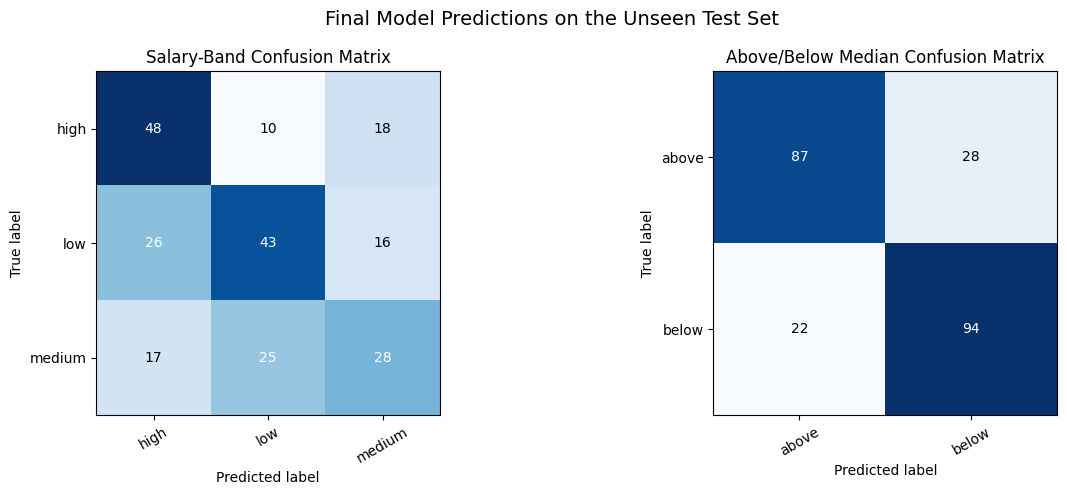

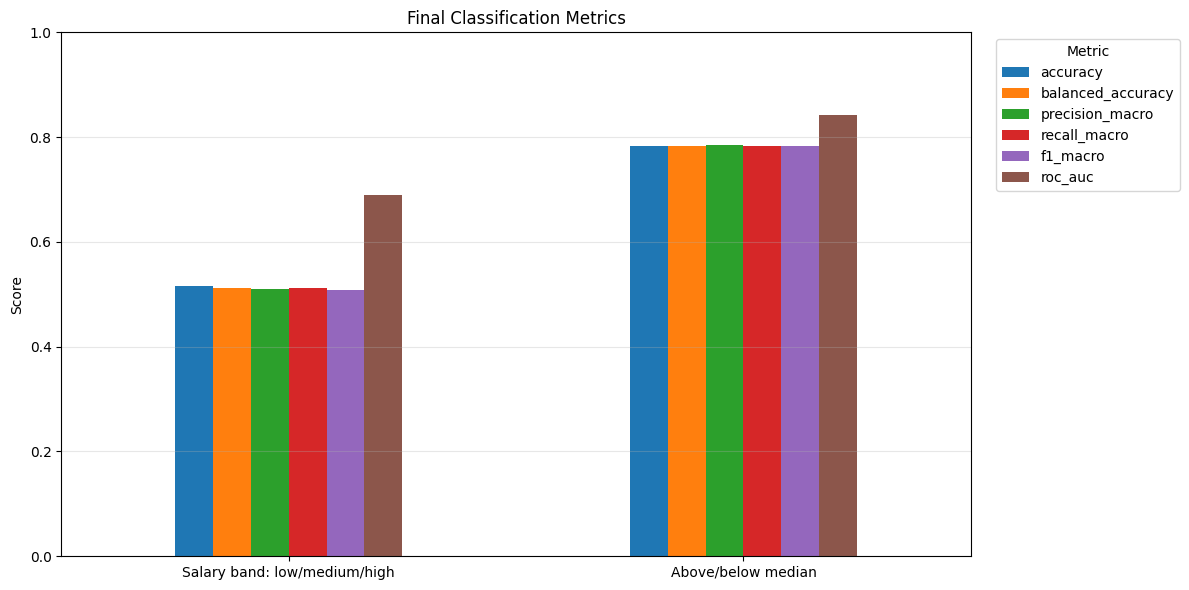

In [271]:
import os
import matplotlib.pyplot as plt

EVALUATION_DIR = "../reports/model_evaluation"
os.makedirs(EVALUATION_DIR, exist_ok=True)

def plot_confusion_matrix(ax, matrix, labels, title):
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(labels)), labels=labels, rotation=30)
    ax.set_yticks(range(len(labels)), labels=labels)
    threshold = matrix.max() / 2
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(
                col, row, matrix[row, col],
                ha="center", va="center",
                color="white" if matrix[row, col] > threshold else "black"
            )
    return image


band_matrix = confusion_matrix(y_test, band_predictions, labels=final_model.classes_)
binary_matrix = confusion_matrix(yb_test, binary_predictions, labels=binary_model.classes_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(
    axes[0], band_matrix, final_model.classes_,
    "Salary-Band Confusion Matrix"
)
plot_confusion_matrix(
    axes[1], binary_matrix, binary_model.classes_,
    "Above/Below Median Confusion Matrix"
)
fig.suptitle("Final Model Predictions on the Unseen Test Set", fontsize=14)
fig.tight_layout()
fig.savefig(
    f"{EVALUATION_DIR}/confusion_matrices.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

metric_columns = ["accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]
metric_plot = metrics_table.set_index("task")[metric_columns]
ax = metric_plot.plot(kind="bar", figsize=(12, 6), ylim=(0, 1), rot=0)
ax.set_title("Final Classification Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{EVALUATION_DIR}/final_model_metrics.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

## 5.4 Compare predictions with true labels and analyze errors

In [272]:
band_error_analysis = model_df.loc[
    X_test.index,
    ["job_id", "role", "seniority_level", "location_region", "salary_band"]
].copy()
band_error_analysis["predicted_band"] = band_predictions
band_error_analysis["correct"] = (
    band_error_analysis["salary_band"] == band_error_analysis["predicted_band"]
)

print("Sample of actual versus predicted salary bands")
display(band_error_analysis.head(10))
print(f"Misclassified three-class records: {(~band_error_analysis['correct']).sum():,}")
print("Most common actual-to-predicted errors")
display(
    band_error_analysis.loc[~band_error_analysis["correct"]]
    .groupby(["salary_band", "predicted_band"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

binary_error_analysis = pd.DataFrame({
    "true_label": yb_test,
    "predicted_label": binary_predictions,
}, index=yb_test.index)
binary_error_analysis["correct"] = (
    binary_error_analysis["true_label"] == binary_error_analysis["predicted_label"]
)
print(f"Misclassified binary records: {(~binary_error_analysis['correct']).sum():,}")

Sample of actual versus predicted salary bands


,job_id,role,seniority_level,location_region,salary_band,predicted_band,correct
6967,5822422896,Project Manager,Senior,Tamil Nadu,low,high,False
7201,5907848164,Digital Marketing,Senior,Unknown,medium,medium,True
6566,5904171684,Data Engineer,Mid,Maharashtra,high,medium,False
6844,5828957584,Product Manager,Senior,Karnataka,high,high,True
6564,5906274262,Data Engineer,Mid,Karnataka,medium,medium,True
130,5837542495,Business Analyst,Senior,Karnataka,high,high,True
3843,5889554240,Digital Marketing,Mid,Maharashtra,low,medium,False
6899,5822428109,Project Manager,Senior,Unknown,low,high,False
1383,5902287266,Data Analyst,Mid,Gujarat,medium,low,False
6684,5903295431,Data Scientist,Mid,Unknown,high,high,True


Misclassified three-class records: 112
Most common actual-to-predicted errors


,salary_band,predicted_band,count
2,low,high,26
5,medium,low,25
1,high,medium,18
4,medium,high,17
3,low,medium,16
0,high,low,10


Misclassified binary records: 50


## 5.5 Interpretation: strengths, weaknesses, and business implications

**Strengths**

- The selected models are tuned using only training data and evaluated on unseen postings.
- Macro-F1 gives equal importance to low, medium, and high salary bands.
- ROC-AUC measures how well the models separate classes across probability thresholds.
- The binary model gives a simpler above/below-median signal for decision-making.

**Weaknesses**

- Salary bands are based on available salary observations, so postings without salary information are not directly labelled for supervised training.
- Errors are expected between neighbouring salary bands because compensation boundaries are not perfectly distinct.
- Role, location, seniority, and detected skills do not capture every salary driver, such as employer size, negotiation, or benefits.

**Business implication**

The model can support early market screening, salary benchmarking, and prioritisation of job opportunities. It should be used as a decision-support signal rather than as a guaranteed salary rule.

## 5.6 Final summary and conclusion

In [273]:
best_band_row = metrics_table.loc[metrics_table["task"].str.startswith("Salary band")].iloc[0]
best_binary_row = metrics_table.loc[metrics_table["task"].str.startswith("Above/below")].iloc[0]

final_summary = pd.DataFrame([
    {
        "task": "Three-class salary band",
        "selected_model": best_name,
        "test_accuracy": best_band_row["accuracy"],
        "test_macro_f1": best_band_row["f1_macro"],
        "test_roc_auc": best_band_row["roc_auc"],
    },
    {
        "task": "Above/below median",
        "selected_model": binary_best,
        "test_accuracy": best_binary_row["accuracy"],
        "test_macro_f1": best_binary_row["f1_macro"],
        "test_roc_auc": best_binary_row["roc_auc"],
    },
])
display(final_summary.round(3))
print("Conclusion: the selected tuned classifiers provide a reproducible salary-market signal from structured job features.")

,task,selected_model,test_accuracy,test_macro_f1,test_roc_auc
0,Three-class salary band,SVM,0.515,0.509,0.689
1,Above/below median,XGBoost,0.784,0.783,0.843


Conclusion: the selected tuned classifiers provide a reproducible salary-market signal from structured job features.


---
# 6. Business Interpretation

Based on our exploratory data analysis and the predictive models developed, we have uncovered the main drivers of compensation in the tech and digital job market. Here are the key actionable insights:

### 1. The Strongest Drivers of Compensation
Across both models (Binary and Salary Band), the highest impact on salary prediction stems from:
* **Role Categorization:** Roles such as `Digital Marketing` and `Graphic Designer` strongly signal specific pay ranges. By contrast, roles like `DevOps / Cloud Engineer` and `Data Engineer` push salaries upwards, as demand outpaces supply.
* **Skill Diversity (`skill_count`):** The total volume of core tech skills a candidate possesses is a critical indicator of salary. Jobs demanding a high number of skills (e.g. cross-functional capabilities) consistently command higher pay.
* **Seniority (`Seniority: ordinal`):** Unsurprisingly, a higher seniority level (Lead, Executive, Senior) dramatically influences the probability of being in a high salary bracket.

### 2. Location Matters (But Maybe Less Than You Think)
* While overall location does impact compensation, specific regional hubs dominate the data. **Karnataka** (India's tech hub, Bangalore) and **Maharashtra** act as significant features pushing salaries higher. 
* However, tech skills and role definition still hold substantially more weight than location alone, indicating an increasingly distributed or skill-driven tech market.

### 3. Contract Types
* `is_full_time` is among the top predictive features. Part-time or contract roles heavily cluster in the lower salary bands, whereas full-time permanent positions secure a premium.

### 4. Precision of Predictive Bands
* The Binary Model effectively identifies whether a role pays above or below the median with high precision, balancing false positives and false negatives smoothly.
* The Band Model struggles slightly more (as distinguishing between 'Low' and 'Medium' involves subtler differences). However, it rarely makes drastic errors (e.g., misclassifying 'Low' as 'High'), providing a reliable safety net for employers aiming to bracket roles for hiring budgets.

**Conclusion:** 
For a recruiter or a hiring manager, the focus should lie on defining the **specific skills required** and the **exact seniority** rather than relying purely on location-based market rates. The models confirm that technical depth and leadership demands dictate the top brackets of the market.
